# FIERY - planning - all together

In [8]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F

from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, get_clusters, plot_img

from skimage.draw import polygon
from sklearn.metrics import roc_auc_score

In [2]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

In [3]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(PATH_labels_pedestrians,
                                                                   PATH_res_pedestrians,
                                                                   flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]
    segm_ped_inst = segm_ped_data["inst"]

In [4]:
if False:

    flow_ped_y, _, _, _ = get_results(PATH_labels_pedestrians,
                                                   PATH_res_pedestrians,
                                                    results_name = "instance_flow", label_name = "flow", 
                                                   flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("flow_results_pedestrains_e12_only_y.npz", y=flow_ped_y)

else:
    flow_ped_data = np.load("flow_results_pedestrains_e12_only_y.npz")

    flow_ped_y = flow_ped_data["y"]
    #center_ped_p = center_ped_data["p"]

In [5]:
#data_costmaps = np.load("results_all_costmaps_object_cal_n=%i_09_01_23_pw_fix.npz" % 0)

#segms_objcal = data_costmaps["costmaps_cal"] #, ps_cal = presence_ps_all_cal_fix

In [6]:
data_costmaps = np.load("results_all_costmaps_object_cal_n=%i_03_23_23_pw_%s.npz" % (0, "test"), allow_pickle=True)

segms_objcal = data_costmaps["costmaps_cal"] #, ps_cal = presence_ps_all_cal_fix

In [7]:
segms_objcal[0].shape

(200, 200)

### Functions for planning

In [8]:
def get_segm_future(idx):
    
    future_ys = [segm_ped_y[0,idx]]

    IDs = np.unique(segm_ped_inst[0,idx])[1:]  # Skip 0 value, as it is not ID

    # Prepare xys for each ID
    xys_by_IDs = {}
    for ID in IDs:
        #print(ID)

        xys = []
        for y,x in np.array(np.where(segm_ped_inst[0,idx] == ID)).T:
            xys.append([x,y])

        xys_by_IDs[ID] = xys

    for seq in range(segm_ped_y.shape[0]-1):  # -1 because no information for 5th timestep
        #print(seq)
        future_y = np.zeros_like(segm_ped_y[0,idx])

        #assert np.all(IDs == np.unique(segm_ped_inst[seq,idx])[1:])  # TODO check if it is needed

        for ID in IDs:
            y_dirs = flow_ped_y[seq, idx, 0][segm_ped_inst[seq, idx] == ID]
            x_dirs = flow_ped_y[seq, idx, 1][segm_ped_inst[seq, idx] == ID]

            assert len(np.unique(y_dirs)) <= 1
            assert len(np.unique(x_dirs)) <= 1
            
            if len(np.unique(y_dirs)) == 0 or len(np.unique(y_dirs)) == 0:
                y_dirs = [0]
                x_dirs = [0]

            new_xys = []

            for x,y in xys_by_IDs[ID]:
                
                if y_dirs[0] == 255 or x_dirs[0] == 255:
                    #print("Should not get here!")
                    continue

                
                new_y, new_x = (np.min([199, (int(y - y_dirs[0]))]), np.min([199, int(x - x_dirs[0])]))

                future_y[new_y, new_x] = 1

                new_xys.append([new_x, new_y])

            xys_by_IDs[ID] = new_xys


        future_ys.append(future_y)
        
    return np.array(future_ys)
    

In [9]:
# https://github.com/peiyunh/ff/blob/master/test.py

def evaluate_box_coll(segm_y, trajectory):
    T, H, W = segm_y.shape
    collisions = np.full(T, False)
    for t in range(T):  # Timestep
        x, y, theta = trajectory[t]
        theta = -theta
        corners = np.array([
            (-1, -2, 1),  # back left corner
            (1, -2, 1),   # back right corner
            (1, 2, 1),    # front right corner
            (-1, 2, 1),   # front left corner
            
            #(-0.8, -1.5, 1),  # back left corner
            #(0.8, -1.5, 1),   # back right corner
            #(0.8, 2.5, 1),    # front right corner
            #(-0.8, 2.5, 1),   # front left corner
            
        ])
        tf = np.array([
            [np.cos(theta), -np.sin(theta), x],
            [np.sin(theta), np.cos(theta), y],
            [0, 0, 1],
        ])
        xx, yy = tf.dot(corners.T)[:2]
        rr, cc = polygon(yy, xx)
        I = np.logical_and(
            np.logical_and(rr >= 0, rr < H),
            np.logical_and(cc >= 0, cc < W),
        )
        collisions[t] = np.any(segm_y[t, rr[I], cc[I]])
    return collisions


def get_vehicle_loc(trajectory, t):

    x, y, theta = trajectory[t]
    
    theta = -theta
    
    corners = np.array([
        (-1, -2, 1),  # back left corner
        (1, -2, 1),   # back right corner
        (1, 2, 1),    # front right corner
        (-1, 2, 1),   # front left corner
    ])
    tf = np.array([
        [np.cos(theta), -np.sin(theta), x],
        [np.sin(theta), np.cos(theta), y],
        [0, 0, 1],
    ])
    xx, yy = tf.dot(corners.T)[:2]
    rr, cc = polygon(yy, xx)
    I = np.logical_and(
        np.logical_and(rr >= 0, rr < 200),
        np.logical_and(cc >= 0, cc < 200),
    )
    return rr, cc

def get_traj_loc(x, y, theta, length, width = 4):
    
    theta = -theta
    length = length + 4 # For car size
    
    #print(width)
    
    corners = np.array([
        (-width/2, -length/2, 1),  # back left corner
        (width/2, -length/2, 1),   # back right corner
        (width/2, length/2, 1),    # front right corner
        (-width/2, length/2, 1),   # front left corner
    ])
    tf = np.array([
        [np.cos(theta), -np.sin(theta), x],
        [np.sin(theta), np.cos(theta), y],
        [0, 0, 1],
    ])
    xx, yy = tf.dot(corners.T)[:2]
    rr, cc = polygon(yy, xx)
    I = np.logical_and(
        np.logical_and(rr >= 0, rr < 200),
        np.logical_and(cc >= 0, cc < 200),
    )
    return rr, cc

In [10]:
def get_seg_from_poly(traj, seq):
    seg = np.zeros((200, 200))

    poly = np.array(get_vehicle_loc(traj, t = seq)).T


    for x, y in poly:
        seg[x,y] = 1
        
    return seg

## Generate trajectories

In [11]:
speeds = [10] # 3.5m per 0.5s, so 7 meters per second.  # 10 pixels = 5 meters
rotations = np.arange(0, 0.325, 0.025)
rotations2 = [] # np.arange(0.7, 0.9, 0.1)
x_speeds = [-1.5,-1, -0.5, 0, 0.5, 1, 1.5]# for lane changes or similar (minimal rotation)

center = [100, 100]
timesteps = 5
trajectories = []

for speed in speeds:
    for rot in rotations:  # Mellow turn
        
        traj = []
        traj2 = []
        
        for t in range(timesteps):       
            if t == 0:
                traj.append([center[0], center[1], 0])  # x, y, rotation
                traj2.append([center[0], center[1], 0])
            else:
                #x_d = np.math.sin(rot)*speed # sin(a) = a/c  # a - vastaskaatet
                #y_d = np.math.cos(rot)*speed
                #traj.append([traj[-1][0] - x_d, traj[-1][1] - y_d, traj[-1][2] + rot])
                #traj2.append([traj2[-1][0] + x_d, traj2[-1][1] - y_d, traj2[-1][2] - rot])
                
                x_d = np.math.sin(traj[-1][2] + rot)*speed # sin(a) = a/c  # a - vastaskaatet
                y_d = np.math.cos(traj2[-1][2] - rot)*speed
                traj.append([traj[-1][0] - x_d, traj[-1][1] - y_d, traj[-1][2] + rot])
                traj2.append([traj2[-1][0] + x_d, traj2[-1][1] - y_d, traj2[-1][2] - rot])            
    
        trajectories.append(traj)
        trajectories.append(traj2)
        
        
    for rot in rotations2:  # Sharper turn, in the 1st timestep, then more mellow
        
        traj = []
        traj2 = []
        
        for t in range(timesteps):       
            if t == 0:
                traj.append([center[0], center[1], 0])  # x, y, rotation
                traj2.append([center[0], center[1], 0])
            else:

                if traj[-1][2] != 0:
                    new_rot = rot/traj[-1][2]/3                    
                else:
                    new_rot = rot

                x_d = np.math.sin(traj[-1][2] + new_rot)*speed # sin(a) = a/c  # a - vastaskaatet
                y_d = np.math.cos(traj2[-1][2] - new_rot)*speed
                traj.append([traj[-1][0] - x_d, traj[-1][1] - y_d, traj[-1][2] + new_rot])
                traj2.append([traj2[-1][0] + x_d, traj2[-1][1] - y_d, traj2[-1][2] - new_rot])
            
        trajectories.append(traj)
        trajectories.append(traj2)
    
    for i, x_speed in enumerate(x_speeds):  # Minimal turn, just aligning to new lane
        
        traj2 = []
        
        for t in range(timesteps):       
            if t == 0:
                traj2.append([center[0], center[1], 0])  # x, y, rotation
            else:
                traj2.append([traj2[-1][0] - x_speed, traj2[-1][1] - speed, 0])
            
    
        #trajectories.append(traj2)

trajectories = np.unique(trajectories, axis=0)
trajectories = np.array(trajectories)

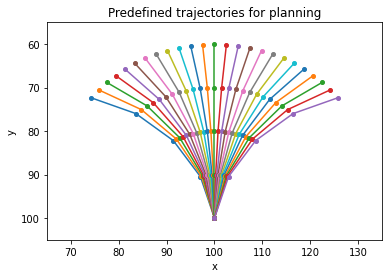

In [12]:
for t in trajectories:
    plt.plot(t[:, 0], t[:, 1], marker = "o", markersize=4)

plt.xlim(65, 135)
plt.ylim(55, 105)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predefined trajectories for planning")
plt.gca().invert_yaxis()

plt.savefig("fig_predefined_trajectories.pdf", bbox_inches="tight")

In [13]:
trajectories.shape

(25, 5, 3)

In [14]:
trajectories[0]

array([[100.        , 100.        ,   0.        ],
       [ 97.04479793,  90.44663511,   0.3       ],
       [ 91.3983732 ,  82.19327896,   0.6       ],
       [ 83.5651041 ,  75.97717928,   0.9       ],
       [ 74.24471324,  72.35360173,   1.2       ]])

## Corridor for trajectories

Kas terve teekonna põhjal hinnang, või autoasukoha järgi pärast 0.5 sekundit?

In [15]:
trajectories[0]

array([[100.        , 100.        ,   0.        ],
       [ 97.04479793,  90.44663511,   0.3       ],
       [ 91.3983732 ,  82.19327896,   0.6       ],
       [ 83.5651041 ,  75.97717928,   0.9       ],
       [ 74.24471324,  72.35360173,   1.2       ]])

In [16]:
ego_vehicle_len = 8

traj_masks = []
traj_masks_step = []

for t in trajectories:

    traj_data = []
    
    for i in range(t.shape[0]-1):
        #print(i)
        x_mid, y_mid =  ((t[i, 0] + t[i+1,0])/2, (t[i, 1] + t[i+1,1])/2)
        t_len = np.round(np.sqrt((t[i, 0] - t[i+1,0])**2 + (t[i, 1] - t[i+1,1])**2), 0) + ego_vehicle_len
        #print(t_len)
        theta = t[i+1, 2]  # Rotation for theta

        traj_data.append([x_mid, y_mid, theta, t_len])
        
    traj_mask = np.zeros((200, 200))
    
    traj_steps = []

    for i, traj_d in enumerate(traj_data):
        
        traj_step = np.zeros((200, 200))  # FOr adding traj_masks for each timestep
        
        #print(i)
        traj_poly = np.array(get_traj_loc(*traj_d, width=4)).T
        
        for x, y in traj_poly:
            traj_mask[x,y] = 1 # i+1 could add this to separate timesteps     
            traj_step[x,y] = 1
            
        traj_steps.append(traj_step)
            
    traj_masks.append(traj_mask.astype(bool))
    traj_masks_step.append(traj_steps)

In [17]:
traj_mask.max()

1.0

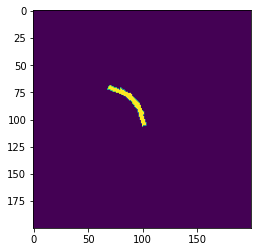

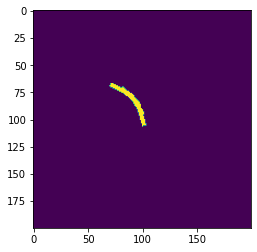

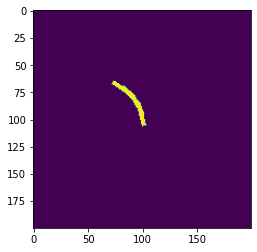

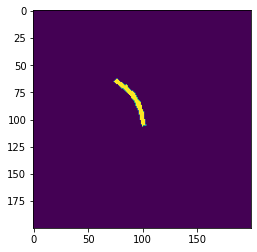

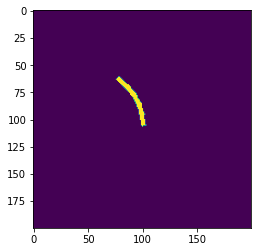

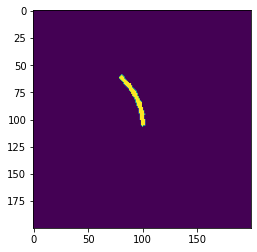

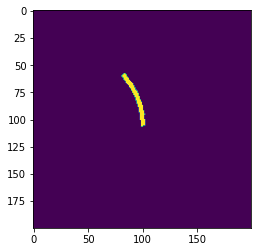

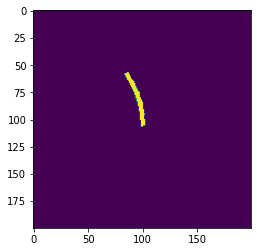

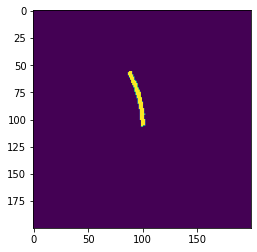

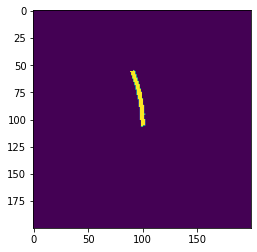

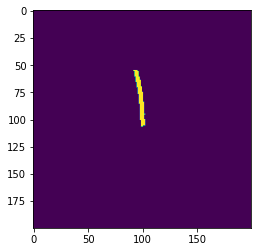

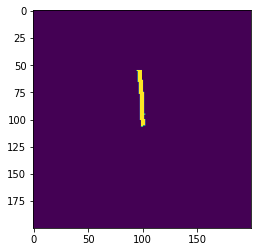

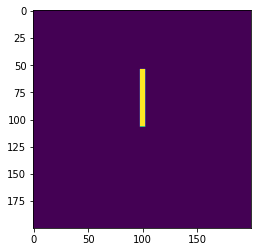

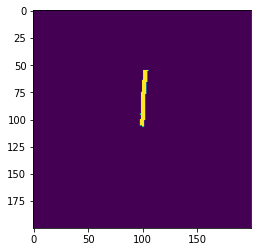

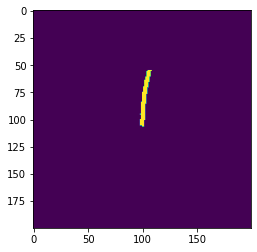

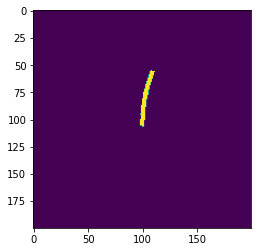

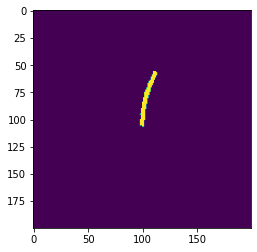

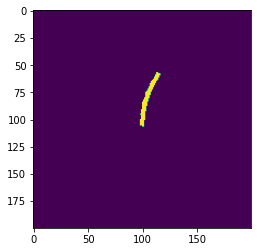

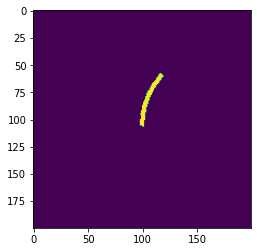

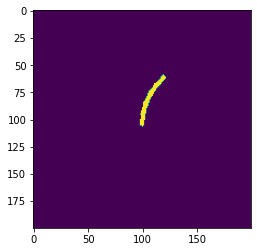

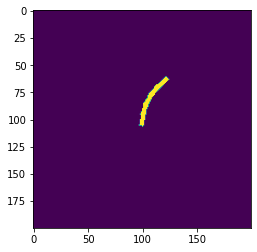

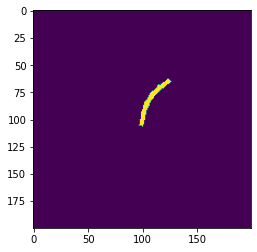

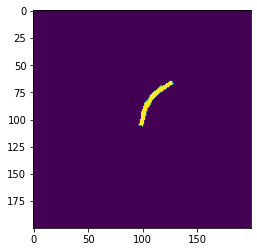

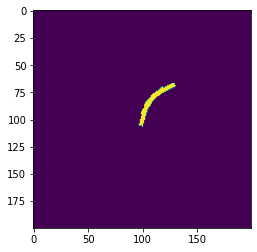

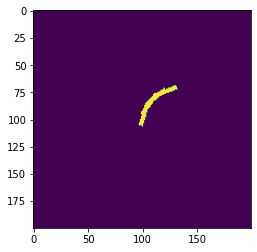

In [18]:
for traj_mask in traj_masks:
    plt.imshow(traj_mask)
    plt.show()

In [19]:
np.save("trajectory_masks_09_01_23", traj_masks)

In [20]:
traj_masks = np.load("trajectory_masks_09_01_23.npy")

### Get collisions for 4th timestep using masks

In [21]:
import numpy as np
from matplotlib import pyplot as plt

0
(array([ 84,  84,  84,  84,  84,  85,  85,  85,  85,  85,  86,  86,  86,
        86,  86,  87,  87,  87,  87,  87,  88,  88,  88,  88,  88,  89,
        89,  89,  89,  89,  90,  90,  90,  90,  90,  91,  91,  91,  91,
        91,  92,  92,  92,  92,  92,  93,  93,  93,  93,  93,  94,  94,
        94,  94,  94,  95,  95,  95,  95,  95,  96,  96,  96,  96,  96,
        97,  97,  97,  97,  97,  98,  98,  98,  98,  98,  99,  99,  99,
        99,  99, 100, 100, 100, 100, 100, 101, 101, 101, 101, 101, 102,
       102, 102, 102, 102, 103, 103, 103, 103, 103, 104, 104, 104, 104,
       104, 105, 105, 105, 105, 105, 106, 106, 106, 106, 106]), array([ 98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,
        99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101,
       102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99,
       100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 10

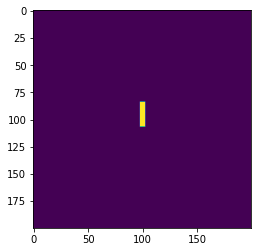

1
(array([74, 74, 74, 74, 74, 75, 75, 75, 75, 75, 76, 76, 76, 76, 76, 77, 77,
       77, 77, 77, 78, 78, 78, 78, 78, 79, 79, 79, 79, 79, 80, 80, 80, 80,
       80, 81, 81, 81, 81, 81, 82, 82, 82, 82, 82, 83, 83, 83, 83, 83, 84,
       84, 84, 84, 84, 85, 85, 85, 85, 85, 86, 86, 86, 86, 86, 87, 87, 87,
       87, 87, 88, 88, 88, 88, 88, 89, 89, 89, 89, 89, 90, 90, 90, 90, 90,
       91, 91, 91, 91, 91, 92, 92, 92, 92, 92, 93, 93, 93, 93, 93, 94, 94,
       94, 94, 94, 95, 95, 95, 95, 95, 96, 96, 96, 96, 96]), array([ 98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,
        99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101,
       102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99,
       100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,
        98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 10

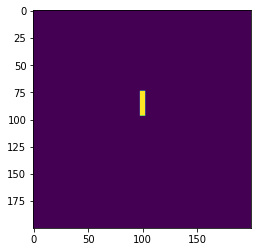

2
(array([64, 64, 64, 64, 64, 65, 65, 65, 65, 65, 66, 66, 66, 66, 66, 67, 67,
       67, 67, 67, 68, 68, 68, 68, 68, 69, 69, 69, 69, 69, 70, 70, 70, 70,
       70, 71, 71, 71, 71, 71, 72, 72, 72, 72, 72, 73, 73, 73, 73, 73, 74,
       74, 74, 74, 74, 75, 75, 75, 75, 75, 76, 76, 76, 76, 76, 77, 77, 77,
       77, 77, 78, 78, 78, 78, 78, 79, 79, 79, 79, 79, 80, 80, 80, 80, 80,
       81, 81, 81, 81, 81, 82, 82, 82, 82, 82, 83, 83, 83, 83, 83, 84, 84,
       84, 84, 84, 85, 85, 85, 85, 85, 86, 86, 86, 86, 86]), array([ 98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,
        99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101,
       102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99,
       100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,
        98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 10

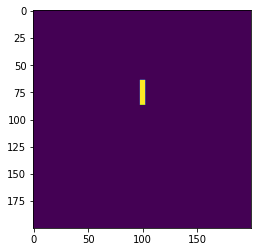

3
(array([54, 54, 54, 54, 54, 55, 55, 55, 55, 55, 56, 56, 56, 56, 56, 57, 57,
       57, 57, 57, 58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 60, 60, 60, 60,
       60, 61, 61, 61, 61, 61, 62, 62, 62, 62, 62, 63, 63, 63, 63, 63, 64,
       64, 64, 64, 64, 65, 65, 65, 65, 65, 66, 66, 66, 66, 66, 67, 67, 67,
       67, 67, 68, 68, 68, 68, 68, 69, 69, 69, 69, 69, 70, 70, 70, 70, 70,
       71, 71, 71, 71, 71, 72, 72, 72, 72, 72, 73, 73, 73, 73, 73, 74, 74,
       74, 74, 74, 75, 75, 75, 75, 75, 76, 76, 76, 76, 76]), array([ 98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,
        99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101,
       102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99,
       100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100, 101, 102,
        98,  99, 100, 101, 102,  98,  99, 100, 101, 102,  98,  99, 100,
       101, 102,  98,  99, 100, 101, 102,  98,  99, 10

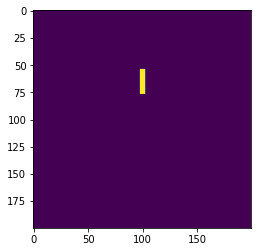

In [22]:
for k in range(4): # Traj mask steps, for each future steps?
    print(k)
    plt.imshow(traj_masks_step[12][k])
    print(np.where(traj_masks_step[12][k] == 1))
    plt.show()

### Collisions for each timestep separately

In [23]:
#np.sum(futures_y[1][traj_masks_step[0][0].astype(bool)])

In [24]:
collisions_cor = []

for i in range(segm_ped_y.shape[1]):
    
    if i % 100 == 0:
        print(i)
    
    traj_cols = np.zeros(len(traj_masks))
    futures_y = get_segm_future(i)
    
    for j, traj_mask in enumerate(traj_masks_step):
        
        #print(len(traj_mask))
        
        overlaps = 0
        
        for k in range(4):
            overlaps += np.sum(futures_y[k+1][traj_mask[k].astype(bool)])
        
        if overlaps > 0:
            traj_cols[j] = 1
        #traj_cols.
        
    collisions_cor.append(traj_cols)
    
    break
    
collisions_cor = np.array(collisions_cor)

if len(collisions_cor) > 2:
    print("Saving data!")
    np.save("collisions_5meter_corridor_step_23_03_23.npy", np.array(collisions_cor))

0


In [25]:
collisions_cor = []

for i in range(segm_ped_y.shape[1]):
    
    if i % 100 == 0:
        print(i)
    
    traj_cols = np.zeros(len(traj_masks))
    futures_y = get_segm_future(i)
    
    for j, traj_mask in enumerate(traj_masks):
        overlaps = np.sum(futures_y[4][traj_mask])
        
        if overlaps > 0:
            traj_cols[j] = 1
        #traj_cols.
        
    collisions_cor.append(traj_cols)
    
    break
    
collisions_cor = np.array(collisions_cor)

if len(collisions_cor) > 2:
    print("Saving data!")
    np.save("collisions_5meter_corridor_05_01_22.npy", np.array(collisions_cor))

0


### All timesteps checked

Should we check the exact location of the vehicle for each timestep?

In [26]:
futures_y[1:].shape

(4, 200, 200)

In [27]:
collisions_cor = []

for i in range(segm_ped_y.shape[1]):
    
    if i % 100 == 0:
        print(i)
    
    traj_cols = np.zeros(len(traj_masks))
    futures_y = get_segm_future(i)
    
    for j, traj_mask in enumerate(traj_masks):
        overlaps = np.sum(np.sum(futures_y, axis=0)[traj_mask])  # TODO: take out 0th timestep?
        
        if overlaps > 0:
            traj_cols[j] = 1
        #traj_cols.
        
    collisions_cor.append(traj_cols)
    
    break
    
collisions_cor = np.array(collisions_cor)

if len(collisions_cor) > 2:
    print("Saving data!")
    np.save("collisions_5meter_corridor_5timesteps_23_03_23.npy", np.array(collisions_cor))

0


In [28]:
collisions_cor = np.load("collisions_5meter_corridor_5timesteps_23_03_23.npy")
# "collisions_5meter_corridor_05_01_22.npy"

In [29]:
collisions_cor = np.load("collisions_5meter_corridor_4timesteps_23_03_23.npy")


In [3]:
collisions_cor = np.load("collisions_5meter_corridor_step_23_03_23.npy")



In [ ]:
# Total collisions:

In [6]:
collisions_cor.sum()

6524.0

In [32]:
collisions_cor.shape

(5119, 25)

In [33]:
np.sum(collisions_cor)/(5119*25)  # 5 timesteps

0.050978706778667705

In [34]:
np.sum(collisions_cor)/(5119*25)  # 4 timesteps

0.050978706778667705

In [35]:
np.sum(collisions_cor)/(5119*25)  # 4th timestep

0.050978706778667705

In [36]:
np.sum(collisions_cor)/(5119*25)  # 4 timesteps separately for each step

0.050978706778667705

### Get costmaps for trajectory masks

In [37]:
costmaps_cor = []

for i in range(segm_ped_p.shape[1]):
    
    if i % 100 == 0:
        print(i)
    
    traj_costs = np.zeros(len(traj_masks))
    
    for j, traj_mask in enumerate(traj_masks):
        traj_cost = np.sum(segm_ped_p[0,i][traj_mask])   ## NB! Added 0 for current timestep, instead of 4 for future     
        traj_costs[j] = traj_cost
        
    costmaps_cor.append(traj_costs)
    
    break
    
costmaps_cor = np.array(costmaps_cor)

if len(costmaps_cor) > 2:
    print("Saving data!")
    np.save("costmaps_5meter_corridor_uncal_f0_06_01_22.npy", np.array(costmaps_cor))

0


In [38]:
costmaps_cor = np.load("costmaps_5meter_corridor_uncal_f0_06_01_22.npy")

### Calibrated scores

In [39]:
nr_future = 0  ## NB! Added 0 for current timestep, instead of 4 for future

In [40]:
from betacal import BetaCalibration
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from helper import get_indices_split

In [41]:
indices_val, indices_test = get_indices_split(test_size=0.8, random_state=1001)

In [42]:
indices_test[:5]

[1829, 1188, 2616, 3056, 2792]

In [43]:
segm_ped_p_val = segm_ped_p[nr_future, indices_val,]
segm_ped_y_val = segm_ped_y[nr_future, indices_val,]

segm_ped_p_test = segm_ped_p[nr_future, indices_test,]
segm_ped_y_test = segm_ped_y[nr_future, indices_test,]

#nr_future = 0

ys_pxl_val = segm_ped_y_val.reshape(-1) 
preds_pxl_val = segm_ped_p_val.reshape(-1)

ys_pxl_test = segm_ped_y_test.reshape(-1) 
preds_pxl_test = segm_ped_p_test.reshape(-1)

In [44]:
#model = BetaCalibration()
model = IsotonicRegression()
model.fit(preds_pxl_val, ys_pxl_val)

IsotonicRegression()

In [45]:
np.random.seed(442)
sample_indices = np.random.choice(np.arange(0, preds_pxl_test.shape[0]), size = 10000000, replace = False)

In [46]:
preds_pxl_cal_pw = model.predict(preds_pxl_test)

In [47]:
preds_pxl_cal_pw[np.isnan(preds_pxl_cal_pw)] = 1/preds_pxl_val.shape[0]

In [48]:
samp_preds_cal_pw = preds_pxl_cal_pw[sample_indices]
samp_ys_cal_pw = ys_pxl_test[sample_indices]

In [49]:
samp_preds = preds_pxl_test[sample_indices]
samp_ys = ys_pxl_test[sample_indices]

In [50]:
print("Uncal NLL:", log_loss(samp_ys.flatten(), samp_preds))

Uncal NLL: 0.0035624725060141626


In [51]:
print("Cal NLL:", log_loss(samp_ys_cal_pw.flatten(), samp_preds_cal_pw.astype("float64")))

Cal NLL: 0.003290865913145495


In [52]:
np.array(indices_test).shape

(4091,)

In [53]:
### Correlation on the test data

In [54]:
from time import time

In [55]:
segm_ped_p[0,0].shape

(200, 200)

In [56]:
start_time = time()

costmaps_cor = []

for i in indices_test:
    
    if i % 100 == 0:
        pass
        #print(i)
    
    traj_costs = np.zeros(len(traj_masks))
    
    for j, traj_mask in enumerate(traj_masks):
        traj_cost = np.sum(segm_ped_p[nr_future,i][traj_mask])        
        traj_costs[j] = traj_cost
        
    costmaps_cor.append(traj_costs)
    
    #break
    
costmaps_cor = np.array(costmaps_cor)

end_time = time()
print("Total time:", end_time - start_time)
print("Time per iteration:", (end_time - start_time)/len(indices_test))

if len(costmaps_cor) > 2:
    print("Saving data!")
    np.save("costmaps_5meter_corridor_test_uncal_f0_23_03_23.npy", np.array(costmaps_cor))

Total time: 0.9341201782226562
Time per iteration: 0.00022833541388967397
Saving data!


In [57]:
costmaps_cor = np.load("costmaps_5meter_corridor_test_uncal_f0_23_03_23.npy")

In [58]:
start_time = time()

costmaps_cor_cal = []

for count, i in enumerate(indices_test):
    
    if count % 100 == 0:
        print(count)
    
    traj_costs = np.zeros(len(traj_masks))
    
    segm_cal = model.predict(segm_ped_p[nr_future, i].flatten())
    segm_cal[np.isnan(segm_cal)] = 1/preds_pxl_val.shape[0]
    segm_cal = np.clip(segm_cal, 1/preds_pxl_val.shape[0], 1)
    segm_cal_2d = segm_cal.reshape(200,200)
    
    for j, traj_mask in enumerate(traj_masks):
        
        traj_cost = np.sum(segm_cal_2d[traj_mask])        
        traj_costs[j] = traj_cost
        
    costmaps_cor_cal.append(traj_costs)
    
    
costmaps_cor_cal = np.array(costmaps_cor_cal)

end_time = time()
print("Total time:", end_time - start_time)
print("Time per iteration:", (end_time - start_time)/len(indices_test))


if len(costmaps_cor_cal) > 2:
    print("Saving data!")
    np.save("costmaps_5meter_corridor_test_cal_f0_23_03_23.npy", np.array(costmaps_cor_cal))

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
Total time: 4.927555561065674
Time per iteration: 0.0012044868152201599
Saving data!


In [59]:
costmaps_cor_cal = np.load("costmaps_5meter_corridor_test_cal_f0_23_03_23.npy")

### Use object calibrated costmaps for trajectory ranking

In [60]:
costmaps_cor_objcal = []

for i in range(len(indices_test)):
    
    if i % 100 == 0:
        pass
        #print(i)
    
    traj_costs = np.zeros(len(traj_masks))
    
    for j, traj_mask in enumerate(traj_masks):
        traj_cost = np.sum(segms_objcal[i][traj_mask])        
        traj_costs[j] = traj_cost
        
    costmaps_cor_objcal.append(traj_costs)
    
    break
    
costmaps_cor_objcal = np.array(costmaps_cor_objcal)

if len(costmaps_cor_objcal) > 2:
    print("Saving data!")
    np.save("costmaps_5meter_corridor_test_objcal_f0_23_03_23.npy", np.array(costmaps_cor_objcal))

In [61]:
costmaps_cor_objcal = np.load("costmaps_5meter_corridor_test_objcal_f0_23_03_23.npy")

In [62]:
costmaps_cor_objcal[4]

array([0.03091899, 0.0333168 , 0.03627312, 0.0381099 , 0.04254754,
       0.04778361, 0.05532465, 0.07601293, 0.08213391, 0.10750973,
       0.1505159 , 0.24813499, 0.77223824, 0.82458727, 0.50239872,
       0.22408434, 0.12801947, 0.09711327, 0.20292495, 0.22030401,
       0.04811593, 0.03705848, 0.03408824, 0.02998124, 0.02699252])

### Get undetected object ahead calibrated scores

In [63]:
costmaps_cor_uoa = np.load("results_probabilities_undetected_cal_23_03_23.npy")

In [151]:
#costmaps_cor_uoa_nomatch = np.load("results_probabilities_undetected_cal_nomatching_23_03_23.npy")
costmaps_cor_uoa_nomatch = np.load("results_probabilities_undetected_cal_nomatching_objcal_n_29_03_23.npy")

In [152]:
costmaps_cor_uoa_objcal = np.load("results_probabilities_undetected_cal_objcal_n_29_03_23.npy")

## AUCs of different results

In [164]:
aucs = []
aucs_segmcal = []
aucs_objcal = []
aucs_uoa = []
aucs_uoa_objcal = []
aucs_uoa_objcal_segmcal = []
aucs_all = []
aucs_uoa_nomatch = []

#subset = 

for col_cor, cost_cor, cost_cor_objcal, cost_cor_uoa, cost_cor_cal, cost_cor_uoa_nm, cost_cor_uoa_objcal \
in zip(collisions_cor[indices_test], costmaps_cor, costmaps_cor_objcal, costmaps_cor_uoa, costmaps_cor_cal, 
       costmaps_cor_uoa_nomatch, costmaps_cor_uoa_objcal):
    if np.mean(col_cor) != 0 and np.mean(col_cor) != 1:
        
       # if np.sum(cost_cor) == 0:
            #print("break")
            #break
        #cost_ = cost_cor_objcal #*cost_cor_cal #*cost_cor_cal
        #print(cost_cor2)
        #break
        auc = roc_auc_score(col_cor, cost_cor)
        auc2 = roc_auc_score(col_cor, cost_cor_cal)
        #auc3 = roc_auc_score(col_cor, cost_cor_objcal*0.2)
        #auc4 = roc_auc_score(col_cor, cost_cor_uoa)
        auc5 = roc_auc_score(col_cor, cost_cor_uoa_objcal + cost_cor_objcal*0.2)
        #auc6 = roc_auc_score(col_cor, cost_cor_uoa + cost_cor_objcal*0.2 + cost_cor_cal)
        #auc7 = roc_auc_score(col_cor, cost_cor_uoa + cost_cor_objcal*0.2 + cost_cor_cal + cost_cor)
        auc8 = roc_auc_score(col_cor, cost_cor_uoa_objcal)
        
        aucs.append(auc)
        aucs_segmcal.append(auc2)
        #aucs_objcal.append(auc3)
        #aucs_uoa.append(auc4)
        aucs_uoa_objcal.append(auc5)
        #aucs_uoa_objcal_segmcal.append(auc6)
        #aucs_all.append(auc7)
        aucs_uoa_nomatch.append(auc8)
#roc_auc_score(collisions_cor[indices_test].flatten(), costmaps_cor.flatten())

In [188]:
aucs_test = []

#subset = 

for col_cor, cost_cor, cost_cor_objcal, cost_cor_uoa, cost_cor_cal, cost_cor_uoa_nm in zip(collisions_cor[indices_test], 
                                                                          costmaps_cor, costmaps_cor_objcal, 
                                                                          costmaps_cor_uoa, costmaps_cor_cal,
                                                                         costmaps_cor_uoa_nomatch):
    if np.mean(col_cor) != 0 and np.mean(col_cor) != 1:
        
       # if np.sum(cost_cor) == 0:
            #print("break")
            #break
        #cost_ = cost_cor_objcal #*cost_cor_cal #*cost_cor_cal
        #print(cost_cor2)
        #break
        auc_test = roc_auc_score(col_cor, cost_cor_uoa_nm)

        aucs_test.append(auc_test)

#roc_auc_score(collisions_cor[indices_test].flatten(), costmaps_cor.flatten())

In [189]:
np.mean(aucs_test)

0.871230902717007

In [167]:
import pandas as pd

df = pd.DataFrame(columns = ["Name", "Score"])
df.loc[0] = ["Uncal", np.mean(aucs)]
df.loc[1] = ["Segm. cal.", np.mean(aucs_segmcal)]
#df.loc[2] = ["Object cal.", np.mean(aucs_objcal)]
#df.loc[3] = ["UOA cal.", np.mean(aucs_uoa)]
df.loc[4] = ["Obj. + UOA cal.", np.mean(aucs_uoa_objcal)]
#df.loc[5] = ["Obj. + UOA + segm. cal.", np.mean(aucs_uoa_objcal_segmcal)]
#df.loc[6] = ["All", np.mean(aucs_all)]
df.loc[8] = ["UOA nomatch", np.mean(aucs_uoa_nomatch)]

In [168]:
df

,Name,Score
0,Uncal,0.895200
1,Segm. cal.,0.903931
4,Obj. + UOA cal.,0.904931
8,UOA nomatch,0.882488


In [169]:
from sklearn.metrics import log_loss

In [170]:
nll_test = []

#subset = 

for col_cor, cost_cor, cost_cor_objcal, cost_cor_uoa, cost_cor_cal in zip(collisions_cor[indices_test], costmaps_cor, costmaps_cor_objcal, costmaps_cor_uoa, costmaps_cor_cal):
    #if np.mean(col_cor) != 0 and np.mean(col_cor) != 1:
        
       # if np.sum(cost_cor) == 0:
            #print("break")
            #break
        #cost_ = cost_cor_objcal #*cost_cor_cal #*cost_cor_cal
        #print(cost_cor2)
        #break
    nll = log_loss(col_cor, cost_cor_objcal*0.2+cost_cor_uoa, labels = [0, 1]) 

    nll_test.append(nll)

#roc_auc_score(collisions_cor[indices_test].flatten(), costmaps_cor.flatten())

In [179]:
nll_uncal = log_loss(collisions_cor[indices_test].flatten(), costmaps_cor.flatten())

In [178]:
nll_pwcal = log_loss(collisions_cor[indices_test].flatten(), costmaps_cor_cal.flatten())

In [175]:
nll_objcal = log_loss(collisions_cor[indices_test].flatten(), (costmaps_cor_objcal.flatten()*0.2 + costmaps_cor_uoa.flatten()))

In [205]:
nll_uoa = log_loss(collisions_cor[indices_test].flatten(), (costmaps_cor_uoa_nomatch).flatten())
nll_uoa

0.13176475632920392

In [210]:
for multip in np.arange(0.5, 1.5, 0.1):
    #print(multip)
    print("NLL at %f is %f" % (multip, log_loss(collisions_cor[indices_test].flatten(), (costmaps_cor_uoa_nomatch).flatten()*multip)))

NLL at 0.500000 is 0.138144
NLL at 0.600000 is 0.132540
NLL at 0.700000 is 0.128873
NLL at 0.800000 is 0.127059
NLL at 0.900000 is 0.127468
NLL at 1.000000 is 0.131765
NLL at 1.100000 is 0.209478
NLL at 1.200000 is 0.529723
NLL at 1.300000 is 0.629087
NLL at 1.400000 is 0.631608


### Brier score

In [180]:
brier_uncal = np.mean(np.square(collisions_cor[indices_test].flatten() - np.clip(costmaps_cor.flatten(), 0, 1)))

In [181]:
brier_pwcal = np.mean(np.square(collisions_cor[indices_test].flatten() - np.clip(costmaps_cor_cal.flatten(), 0, 1)))

In [182]:
brier_objcal = np.mean(np.square(collisions_cor[indices_test].flatten() - np.clip((costmaps_cor_objcal.flatten()*0.2 + costmaps_cor_uoa.flatten()), 0, 1)))

In [183]:
brier_uoa = np.mean(np.square(collisions_cor[indices_test].flatten() - np.clip((costmaps_cor_uoa_nomatch.flatten()), 0, 1)))

In [184]:
#nll_uoa = -1
#brier_uoa = -1

In [185]:
df = pd.DataFrame(columns = ["Uncal Segm", "Pw-cal. Segm", "UOA", "Obj. cal. + UOA"])
df.loc["NLL"] = [nll_uncal, nll_pwcal, nll_uoa, nll_objcal]
df.loc["BS"] = [brier_uncal, brier_pwcal, brier_uoa, brier_objcal]
df.loc["AUC"] = [np.mean(aucs), np.mean(aucs_segmcal), np.mean(aucs_uoa_nomatch), np.mean(aucs_uoa_objcal)]

df.T

,NLL,BS,AUC
Uncal Segm,0.605926,0.034923,0.895200
Pw-cal. Segm,0.536661,0.033925,0.903931
UOA,0.131765,0.031434,0.882488
Obj. cal. + UOA,0.269738,0.032463,0.904931


In [126]:
print(df.T.to_latex())

\begin{tabular}{lrrr}
\toprule
{} &       NLL &        BS &       AUC \\
\midrule
Uncal Segm      &  0.605926 &  0.034923 &  0.895200 \\
Pw-cal. Segm    &  0.536661 &  0.033925 &  0.903931 \\
UOA             &  0.128787 &  0.032141 &  0.882922 \\
Obj. cal. + UOA &  0.269738 &  0.032463 &  0.904931 \\
\bottomrule
\end{tabular}



## undetected objects ahead

### Sort costmaps and collisions for uncal and cal

1) Check the count of collisions choosing best trajectory
2) Check where the predictions differ, 

In [86]:
cost_col = np.array([costmaps_cor, collisions_cor[indices_test]]).transpose(1,0,2)
cost_col_cal = np.array([costmaps_cor_cal, collisions_cor[indices_test]]).transpose(1,0,2)

In [87]:
costmaps_cor.shape

(4091, 25)

In [88]:
ind = costmaps_cor.argsort()

cost_col_sorted = []

for i in range(costmaps_cor.shape[0]):
    
    cost_col_sorted.append([costmaps_cor[i, ind[i]], collisions_cor[indices_test][i, ind[i]]])
    
cost_col_sorted = np.array(cost_col_sorted)

In [89]:
ind = costmaps_cor_cal.argsort()

cost_col_cal_sorted = []

for i in range(costmaps_cor_cal.shape[0]):
    
    cost_col_cal_sorted.append([costmaps_cor_cal[i, ind[i]], collisions_cor[indices_test][i, ind[i]]])
    
cost_col_cal_sorted = np.array(cost_col_cal_sorted)

In [90]:
cost_col_cal.shape

(4091, 2, 25)

In [91]:
indices_cc = np.where(np.logical_and(cost_col.sum(axis=(2))[:, 1] > 0, cost_col.sum(axis=(2))[:, 1] < 25))[0]

In [92]:
indices_cc[:100]

array([  2,  10,  14,  18,  19,  23,  25,  27,  28,  31,  36,  44,  45,
        48,  50,  52,  58,  59,  63,  66,  73,  75,  82,  84,  85,  86,
        87,  89,  93,  97,  99, 108, 112, 113, 117, 118, 135, 137, 150,
       162, 163, 165, 169, 170, 172, 175, 179, 180, 182, 184, 191, 196,
       202, 205, 216, 218, 220, 223, 226, 234, 238, 239, 243, 245, 246,
       248, 250, 256, 272, 277, 279, 288, 289, 298, 318, 321, 325, 328,
       332, 337, 339, 340, 345, 348, 349, 352, 353, 360, 365, 366, 369,
       372, 380, 384, 385, 393, 398, 405, 414, 416])

In [93]:
len(aucs)

920

rounding 2

In [94]:
np.mean((np.array(aucs2))[np.where((np.array(aucs2) - aucs_cal2) != 0)])

NameError: name 'aucs2' is not defined

In [ ]:
np.mean(np.array(aucs_cal2)[np.where((np.array(aucs2) - aucs_cal2) != 0)])

round 3

In [ ]:
np.mean((np.array(aucs2))[np.where((np.array(aucs2) - aucs_cal2) != 0)])

In [ ]:
np.mean(np.array(aucs_cal2)[np.where((np.array(aucs2) - aucs_cal2) != 0)])

raw

In [ ]:
np.mean((np.array(aucs))[np.where((np.array(aucs) - aucs_cal) != 0)])

In [ ]:
np.mean((np.array(aucs_cal))[np.where((np.array(aucs) - aucs_cal) != 0)])

## Histogram of aucs differences

Negative means calibrated better, positive uncal better

In [ ]:
np.arange(-1,1,0.05)+0.025

In [ ]:
aucs_diffs = np.array(aucs) - aucs_cal

In [ ]:
np.mean(aucs_diffs[np.where(aucs_diffs != 0)])

In [ ]:
plt.hist(aucs_diffs, bins=15)

In [ ]:
plt.hist(aucs_diffs[np.where(aucs_diffs != 0)], bins=np.arange(-1,1.1,0.1))

## Sorting costmaps and collisions

In [ ]:
np.where(np.abs(aucs_diffs) >= 0.25)

In [ ]:
idx = 188

In [ ]:
cost_col[indices_cc[idx]]

In [ ]:
np.round(cost_col_sorted[indices_cc[idx]],5)

In [ ]:
roc_auc_score(cost_col_sorted[indices_cc[idx]][1], cost_col_sorted[indices_cc[idx]][0])

In [ ]:
cost_col_cal_sorted[indices_cc[idx]]

In [ ]:
roc_auc_score(cost_col_cal_sorted[indices_cc[idx]][1], cost_col_cal_sorted[indices_cc[idx]][0])

##### Best trajectory and number of collision

In [ ]:
cost_col_sorted[:, 1, 0].sum()

In [ ]:
cost_col_cal_sorted[:, 1, 0].sum()